# Ejemplo de material de dia 3

In [1]:
import dask.dataframe as dd
import dask.distributed
from dask.diagnostics.profile import Profiler
from dask.diagnostics.profile_visualize import visualize
from dask.diagnostics.progress import ProgressBar
import matplotlib.pyplot as plt
import seaborn as sns

import requests
import aiohttp

In [2]:
DATASET_URL = "https://raw.githubusercontent.com/gakudo-ai/open-datasets/refs/heads/main/CTA_-_Ridership_-_Daily_Boarding_Totals.csv"

In [3]:
# función que genera un dataset a partir de laURL del conjunto de datos de pasajeros diarios del CTA
def generate_cta_dataset(url=DATASET_URL):
    return dd.read_csv(url)

dataset = generate_cta_dataset()
dataset.head()

,service_date,day_type,bus,rail_boardings,total_rides
0,01/01/2001,U,297192,126455,423647
1,01/02/2001,W,780827,501952,1282779
2,01/03/2001,W,824923,536432,1361355
3,01/04/2001,W,870021,550011,1420032
4,01/05/2001,W,890426,557917,1448343


In [6]:
def prepare_time_series(url=DATASET_URL):
    ddf = dd.read_csv(url, parse_dates=['service_date'])
    ddf['DayOfWeek'] = ddf['service_date'].dt.dayofweek
    ddf['Month'] = ddf['service_date'].dt.month
    ddf['IsWeekend'] = ddf['DayOfWeek'].isin([5, 6]).astype(int)
    return ddf

prepare_time_series().head(10)

,service_date,day_type,bus,rail_boardings,total_rides,DayOfWeek,Month,IsWeekend
0,2001-01-01,U,297192,126455,423647,0,1,0
1,2001-01-02,W,780827,501952,1282779,1,1,0
2,2001-01-03,W,824923,536432,1361355,2,1,0
3,2001-01-04,W,870021,550011,1420032,3,1,0
4,2001-01-05,W,890426,557917,1448343,4,1,0
5,2001-01-06,A,577401,255356,832757,5,1,1
6,2001-01-07,U,375831,169825,545656,6,1,1
7,2001-01-08,W,985221,590706,1575927,0,1,0
8,2001-01-09,W,978377,599905,1578282,1,1,0
9,2001-01-10,W,984884,602052,1586936,2,1,0


In [ ]:
def advanced_time_series_analysis_IA(ddf):
    with Profiler() as prof:
        quarterly_stats = (
            ddf.groupby(ddf['service_date'].dt.to_period('Q')).agg({
                'total_rides': ['mean', 'sum']
            })
        )
        return quarterly_stats

advanced_time_series_analysis_IA(prepare_time_series()).head(10)

total_rides           
                      mean        sum
service_date                         
2001Q1        1.327379e+06  119464146
2001Q2        1.349841e+06  122835569
2001Q3        1.313896e+06  120878456
2001Q4        1.306822e+06  120227586
2002Q1        1.286391e+06  115775156
2002Q2        1.339843e+06  121925678
2002Q3        1.343588e+06  123610141
2002Q4        1.330327e+06  122390113
2003Q1        1.267698e+06  114092778
2003Q2        1.311404e+06  119337749

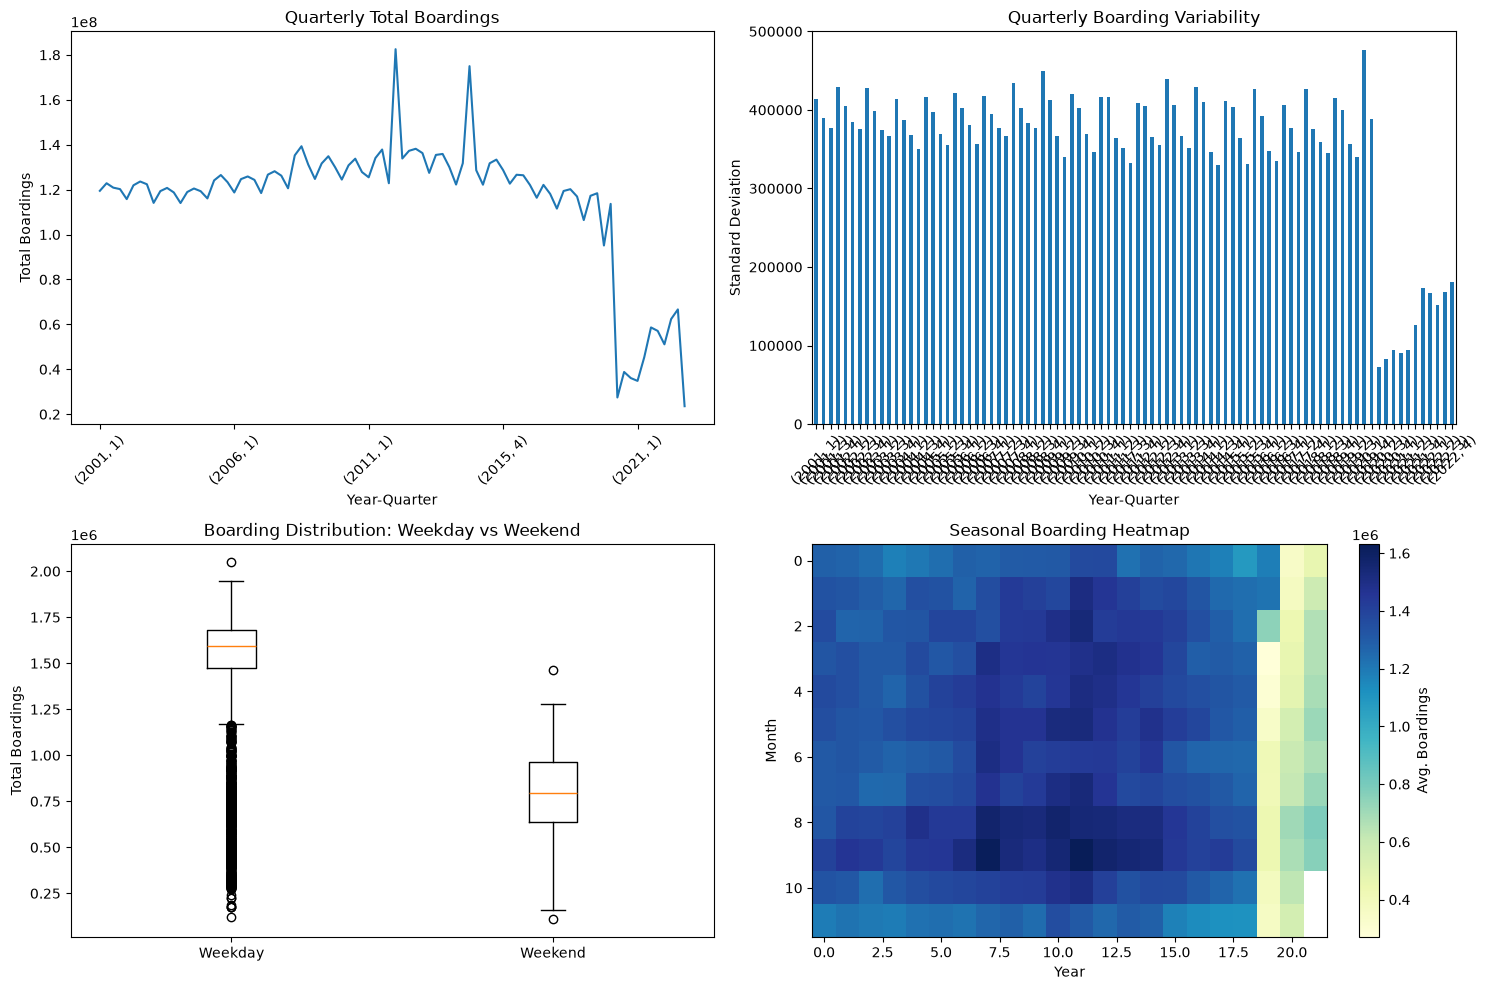

In [12]:
def advanced_time_series_analysis(ddf):
    with Profiler() as prof:
        quarterly_stats = (
            ddf.groupby([
                ddf['service_date'].dt.year,
                ddf['service_date'].dt.quarter
            ])['total_rides']
            .agg(['sum', 'mean', 'count', 'std'])
            .compute()
        )

        pdf = ddf.compute()
        # Creacion de cuatro graficos de visualizacion
        plt.figure(figsize=(15, 10))

        plt.subplot(2, 2, 1)
        quarterly_stats['sum'].plot(kind='line', title='Quarterly Total Boardings')
        plt.xlabel('Year-Quarter')
        plt.ylabel('Total Boardings')
        plt.xticks(rotation=45)

        plt.subplot(2, 2, 2)
        quarterly_stats['std'].plot(kind='bar', title='Quarterly Boarding Variability')
        plt.xlabel('Year-Quarter')
        plt.ylabel('Standard Deviation')
        plt.xticks(rotation=45)

        plt.subplot(2, 2, 3)
        weekday_stats = pdf[pdf['IsWeekend'] == 0]['total_rides']
        weekend_stats = pdf[pdf['IsWeekend'] == 1]['total_rides']
        plt.boxplot([weekday_stats, weekend_stats], tick_labels=['Weekday', 'Weekend'])
        plt.title('Boarding Distribution: Weekday vs Weekend')
        plt.ylabel('Total Boardings')

        plt.subplot(2, 2, 4)
        seasonal_pivot = pdf.pivot_table(
            index='Month',
            columns=pdf['service_date'].dt.year,
            values='total_rides',
            aggfunc='mean'
        )
        plt.imshow(seasonal_pivot, cmap='YlGnBu', aspect='auto')
        plt.colorbar(label='Avg. Boardings')
        plt.title('Seasonal Boarding Heatmap')
        plt.xlabel('Year')
        plt.ylabel('Month')

        plt.tight_layout()
        plt.show()

advanced_time_series_analysis(prepare_time_series())